In [1]:
import tensorflow as tf

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPool2D

from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt 

In [3]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()


print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

# (60k,28,28)   60kimg, 28 height , 28 width 

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


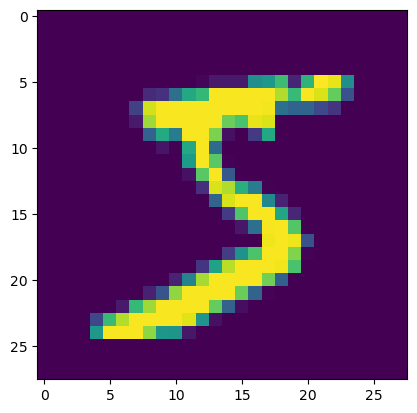

In [4]:
plt.imshow(x_train[0])
plt.show()

In [5]:
x_train=x_train/255.0
x_test=x_test/255.0

In [6]:
print(x_train.min())
print(x_train.max()) 

0.0
1.0


In [7]:
x_train.shape

(60000, 28, 28)

In [8]:
x_test.shape

(10000, 28, 28)

In [9]:
x_train.shape

(60000, 28, 28)

In [10]:
x_train=x_train.reshape(60000, 28, 28,1)
x_test=x_test.reshape(10000, 28, 28,1)

In [11]:
x_train.shape

(60000, 28, 28, 1)

In [12]:
x_test.shape

(10000, 28, 28, 1)

In [13]:
model=Sequential()

In [14]:
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPool2D((2,2)))
model.add(Flatten())
model.add(Dense(units=128,activation='relu'))
model.add(Dense(units=10,activation='softmax'))

c:\Users\beher\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer='rmsprop',
    loss='SparseCategoricalCrossentropy',
    metrics=['accuracy']
)

In [16]:
model.fit(x_train,y_train,batch_size=32,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9514 - loss: 0.1631 - val_accuracy: 0.9785 - val_loss: 0.0647
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9834 - loss: 0.0536 - val_accuracy: 0.9810 - val_loss: 0.0551
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9890 - loss: 0.0369 - val_accuracy: 0.9873 - val_loss: 0.0438
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9922 - loss: 0.0254 - val_accuracy: 0.9871 - val_loss: 0.0385
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9947 - loss: 0.0179 - val_accuracy: 0.9865 - val_loss: 0.0437
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9959 - loss: 0.0130 - val_accuracy: 0.9875 - val_loss: 0.0426
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9975 - loss: 0.0091 - val_accuracy: 0.9864 - val_loss: 0.0447
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9984 - loss: 0

In [17]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9877 - loss: 0.0542


[0.054167188704013824, 0.9876999855041504]

In [18]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [19]:
y_pred=(y_pred>0.5)

In [20]:
from sklearn.metrics import accuracy_score,classification_report

In [21]:
print(y_pred.shape)
print(y_test.shape)

(10000, 10)
(10000,)
